<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [ ]:
# Подключаем библиотеки
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

# Встроенный режим отображения графиков
%matplotlib inline

In [ ]:
# ! Доступ к базе данных требует авторизации.
# ! Данные для подключения не включены в репозиторий по соображениям безопасности.

# Задаем параметры подключения
# DBNAME = 
# USER = 
# PASSWORD = 
# HOST = 
# PORT = 

In [ ]:
# Создаём соединение с заданными параметрами:
# connection = psycopg2.connect(
#     dbname=DBNAME,
#     user=USER,
#     host=HOST,
#     password=PASSWORD,
#     port=PORT
# )

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [4]:
# Текст запроса
# Выбираем количество Id из таблицы вакансий
query_3_1 = f'''SELECT
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
            '''

In [5]:
# Результат запроса
result_3_1 = pd.read_sql_query(query_3_1, connection)
# Вывод результата
print(result_3_1)

   Количество вакансий
0                49197


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\890451426.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_3_1 = pd.read_sql_query(query_3_1, connection)


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [6]:
# Текст запроса
# Выбираем количество Id из таблицы работодателей
query_3_2 = f'''SELECT
                    COUNT(e.id) AS "Количество работодателей"
                FROM employers AS e
            '''

In [7]:
# Результат запроса
result_3_2 = pd.read_sql_query(query_3_2, connection)
# Вывод результата
print(result_3_2)

   Количество работодателей
0                     23501


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\1356997414.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_3_2 = pd.read_sql_query(query_3_2, connection)


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [8]:
# Текст запроса
# Выбираем количество Id из таблицы регионов
query_3_3 = f'''SELECT
                    COUNT(a.id) AS "Количество регионов"
                FROM areas AS a
            '''

In [9]:
# Результат запроса
result_3_3 = pd.read_sql_query(query_3_3, connection)
# Вывод результата
print(result_3_3)

   Количество регионов
0                 1362


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\894205887.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_3_3 = pd.read_sql_query(query_3_3, connection)


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [10]:
# Текст запроса
# Выбираем количество Id из таблицы сфер деятельности
query_3_4 = f'''SELECT
                    COUNT(i.id) AS "Количество сфер деятельности"
                FROM industries AS i
            '''

In [11]:
# Результат запроса
result_3_4 = pd.read_sql_query(query_3_4, connection)
# Вывод результата
print(result_3_4)

   Количество сфер деятельности
0                           294


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2514762835.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_3_4 = pd.read_sql_query(query_3_4, connection)


***

## <center> Выводы по предварительному анализу данных
* В выборке представлено 49 197 вакансий от 23 501 работодателя. В среднем на одного работодателя приходится около 2 вакансий. Можно препдоложить, что крупных работодателей с десятками/сотнями вакансий относительно немного.
* География охватывает 1 362 региона, в среднем - 36 вакансий на регион, что указывает на неравномерное распределение: более чем уверена, что существуют регионы-лидеры (Москва, Санкт-Петербург) с тысячами вакансий и регионы с единичными предложениями.
* Вакансии распределены по 294 сферам деятельности (в среднем 167 вакансий на сферу), что свидетельствует о разнообразном рынке труда с явными отраслевыми лидерами (скорее всего: IT, розничная торговля, производство).

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [12]:
# Текст запроса
# Выбираем названия регионов
# Выбираем количество Id из таблицы вакансий
# Объединяем таблицы по Id региона
# Группируем столбец по названию региона
# Сортируем от большего к меньшему
query_4_1 = f'''SELECT
                    a.name AS "Регион",
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                JOIN areas AS a
                    ON v.area_id = a.id
                GROUP BY a.name
                ORDER BY COUNT(v.id) DESC
            '''

In [13]:
# Результат запроса
result_4_1 = pd.read_sql_query(query_4_1, connection)
# Вывод результата
print(result_4_1)

              Регион  Количество вакансий
0             Москва                 5333
1    Санкт-Петербург                 2851
2              Минск                 2112
3        Новосибирск                 2006
4             Алматы                 1892
..               ...                  ...
764       Тарко-Сале                    1
765    Новоаннинский                    1
766            Бирск                    1
767           Сасово                    1
768             Анна                    1

[769 rows x 2 columns]


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\1041140358.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_4_1 = pd.read_sql_query(query_4_1, connection)


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [14]:
# Текст запроса
# Выбираем количество Id из таблицы вакансий
# В подсчет берем только те вакансии,
# в которых заполнено хотя бы одно из двух полей с зарплатой
query_4_2 = f'''SELECT
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                WHERE 
                    salary_from IS NOT NULL
                    OR salary_to IS NOT NULL
            '''

In [15]:
# Результат запроса
result_4_2 = pd.read_sql_query(query_4_2, connection)
# Вывод результата
print(result_4_2)

   Количество вакансий
0                24073


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2194947564.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_4_2 = pd.read_sql_query(query_4_2, connection)


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [16]:
# Текст запроса
# Вычисляем среднее по нижней границе ЗП
# Вычисляем среднее по верхней границе ЗП
# Округляем результаты
query_4_3 = f'''SELECT
                    ROUND(AVG(v.salary_from), 0) AS "Нижняя граница ЗП",
                    ROUND(AVG(v.salary_to), 0) AS "Верхняя граница ЗП"
                FROM vacancies AS v
            '''

In [17]:
# Результат запроса
result_4_3 = pd.read_sql_query(query_4_3, connection)
# Вывод результата
print(result_4_3)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2901348551.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_4_3 = pd.read_sql_query(query_4_3, connection)


   Нижняя граница ЗП  Верхняя граница ЗП
0            71065.0            110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.

In [18]:
# Текст запроса
# Выбираем пары типов график - трудоустройство
# Считаем количество Id вакансий
# Группируем столбец по типам графика и трудоустройства
# Сортируем от большего к меньшему
query_4_4 = f'''SELECT
                    format('%s — %s', v.schedule, v.employment) AS "График-Занятость",
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                GROUP BY 
                    v.schedule, 
                    v.employment
                HAVING 
                    schedule IS NOT NULL
                    AND employment IS NOT NULL
                ORDER BY COUNT(v.id) DESC
            '''

In [19]:
# Результат запроса
result_4_4 = pd.read_sql_query(query_4_4, connection)
# Вывод результата
print(result_4_4)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2520869704.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_4_4 = pd.read_sql_query(query_4_4, connection)


                          График-Занятость  Количество вакансий
0           Полный день — Полная занятость                35367
1      Удаленная работа — Полная занятость                 7802
2         Гибкий график — Полная занятость                 1593
3   Удаленная работа — Частичная занятость                 1312
4        Сменный график — Полная занятость                  940
5                 Полный день — Стажировка                  569
6        Вахтовый метод — Полная занятость                  367
7        Полный день — Частичная занятость                  347
8      Гибкий график — Частичная занятость                  312
9           Полный день — Проектная работа                  141
10     Удаленная работа — Проектная работа                  133
11              Гибкий график — Стажировка                  116
12    Сменный график — Частичная занятость                  101
13           Удаленная работа — Стажировка                   64
14        Гибкий график — Проектная рабо

5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [20]:
# Текст запроса
# Выбираем столбец требуемого опыта работы
# Считаем количество Id вакансий
# Группируем столбец по требуемому опыту
# Сортируем от меньшего к большему
query_4_5 = f'''SELECT
                    v.experience AS "Опыт",
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                GROUP BY v.experience
                HAVING v.experience IS NOT NULL
                ORDER BY COUNT(v.id)
            '''

In [21]:
# Результат запроса
result_4_5 = pd.read_sql_query(query_4_5, connection)
# Вывод результата
print(result_4_5)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\56305246.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_4_5 = pd.read_sql_query(query_4_5, connection)


                 Опыт  Количество вакансий
0         Более 6 лет                 1337
1           Нет опыта                 7197
2       От 3 до 6 лет                14511
3  От 1 года до 3 лет                26152


***

# <center> Дополнительные исследования данных 

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2858950305.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


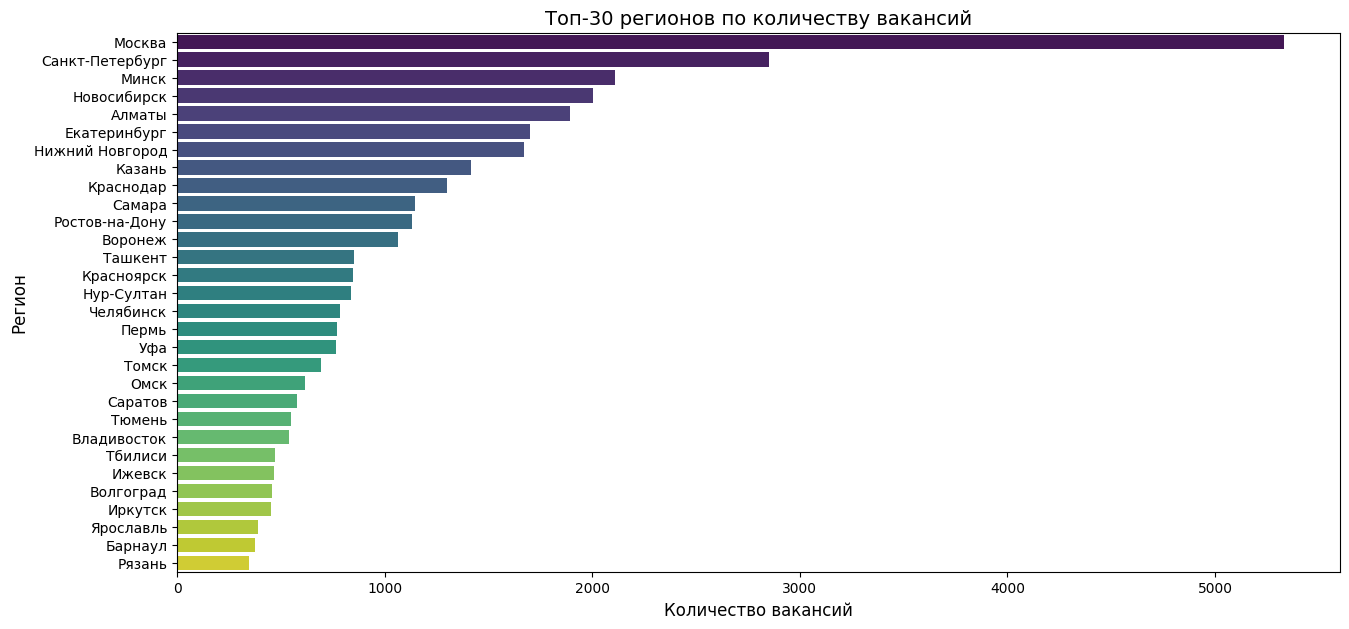

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2858950305.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


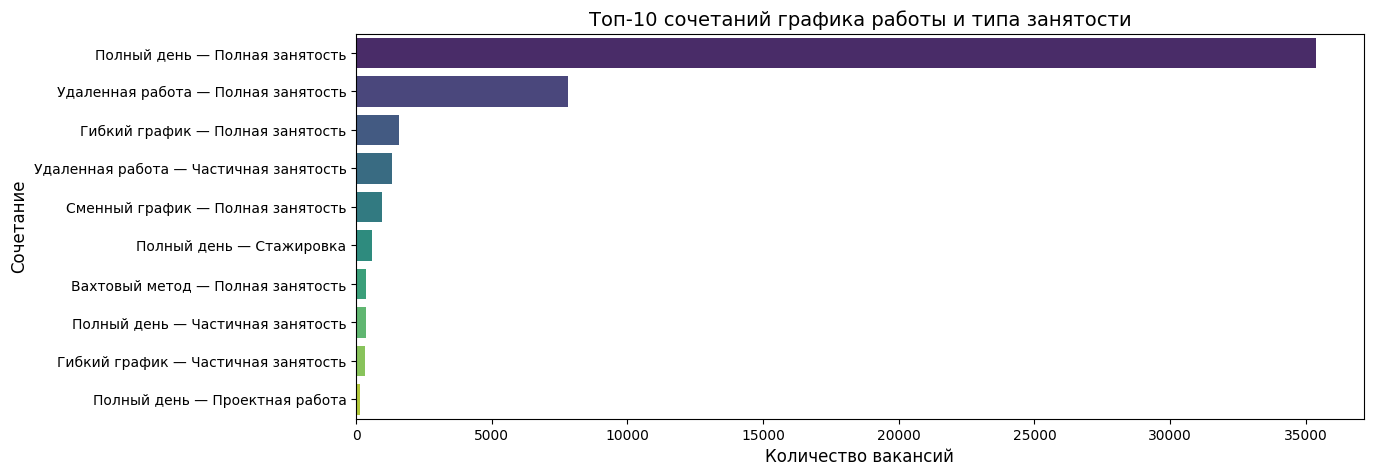

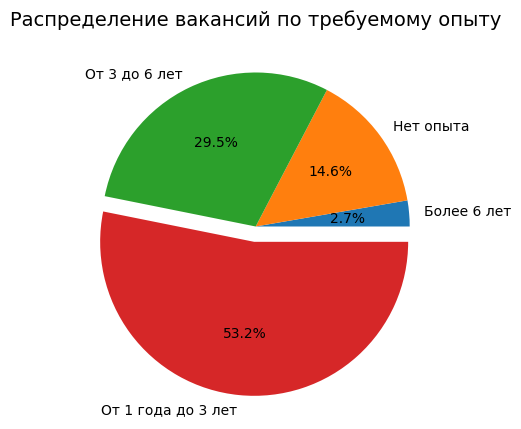

                 Опыт  Нижняя граница ЗП  Верхняя граница ЗП
0         Более 6 лет      150155.510806       199168.109589
1       От 3 до 6 лет      112544.075112       169014.465862
2  От 1 года до 3 лет       64456.363054        94943.690890
3           Нет опыта       34698.743072        56800.697994


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2858950305.py:60: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_optionally = pd.read_sql_query(query_optionally, connection)


In [22]:
# Выведем, на основе полученных данных, несколько графиков для наглядности.
# Выведем столбчатую диаграмму топ-30 регионов по количеству вакансий
top30 = result_4_1.head(30)                                                 # Берем первые 30 значений

plt.figure(figsize=(15, 7))                                                 # Задаем размеры фигуры
sns.barplot(
            data=top30,                                                     # DataFrame с данными
            y='Регион',                                                       # Значения по оси X
            x='Количество вакансий',                                                        # Значения по оси Y
            palette='viridis'                                               # Цвет: viridis
            )

plt.title('Топ-30 регионов по количеству вакансий', fontsize=14)            # Заголовок графика
plt.xlabel('Количество вакансий', fontsize=12)                              # Подписи осей
plt.ylabel('Регион', fontsize=12)                                           # Подписи осей
plt.show()                                                                  # Отображаем график


# Выведем столбчатую диаграмму топ-10 сочетаний графика работы и типа занятости
top10 = result_4_4.head(10)                                                 # Задаем размеры фигуры

plt.figure(figsize=(13, 5))                                                 # Задаем размеры фигуры
sns.barplot(
            data=top10,                                                     # DataFrame с данными
            y='График-Занятость',                                                # Значения по оси X
            x='Количество вакансий',                                                        # Значения по оси Y
            palette='viridis'                                               # Цвет: viridis
            )

plt.title('Топ-10 сочетаний графика работы и типа занятости', fontsize=14)  # Заголовок графика
plt.xlabel('Количество вакансий', fontsize=12)                              # Подписи осей
plt.ylabel('Сочетание', fontsize=12)                                        # Подписи осей
plt.show()                                                                  # Отображаем график


# Выведем круговую диаграмму распределения вакансий по требуемому опыту
plt.figure(figsize=(5, 5))                                                  # Задаем размеры фигуры
plt.pie(
        result_4_5['Количество вакансий'],                                                  # Значения диаграммы
        labels=result_4_5['Опыт'],                                          # Подписи осей
        autopct='%.1f%%',                                                   # Округление значений
        explode = [0, 0, 0, 0.1]                                            # Выдвижение самой большой категории
        );

plt.title('Распределение вакансий по требуемому опыту', fontsize=14)        # Заголовок графика
plt.show()                                                                  # Отображаем график


# Проведем анализ распределения среднего уровня ЗП и опыта
query_optionally = f'''SELECT
                          v.experience AS "Опыт",
                          AVG(v.salary_from) AS "Нижняя граница ЗП",
                          AVG(v.salary_to) AS "Верхняя граница ЗП"
                       FROM vacancies AS v
                       WHERE salary_from IS NOT NULL
                       GROUP BY "Опыт"
                       ORDER BY "Нижняя граница ЗП" DESC;
                    '''
# Результат запроса
result_optionally = pd.read_sql_query(query_optionally, connection)
# Вывод результата
print(result_optionally)

### Исходя из детального анализа вакансий можно сделать следующие выводы:
1. Рынок вакансий сильно сконцентрирован в Москве, Санкт-Петербурге и других крупных городах, тогда как большинство регионов имеют крайне мало предложений.  
Это также видно из графика "Топ-30 регионов по количеству вакансий".

2. 24 073 вакансии из 49 197 (49%) содержат информацию о зарплате => Каждая вторая вакансия не показывает зарплату.  
Многие работодатели предпочитают не указывать вознаграждение открыто.

3. Типичное предложение по зарплате на рынке - от 71 до 110 тысяч рублей.  
Чем меньше опыта, тем ниже ЗП, что наблюдается из дополнительного анализа.

4. Анализ распределения вакансий по форматам работы:
* Классический формат доминирует: 72% вакансий приходится на комбинацию "Полный день - Полная занятость" (35 367 вакансий).  
Также это сильно прослеживается на графике "Топ-10 сочетаний графика работы и типа занятости".  
* Удалённая работа - устойчивый тренд: 18% всех вакансий предлагают удалённый формат.  
* Гибкие форматы набирают популярность: "Гибкий график" присутствует в более 2000 вакансий, преимущественно с полной занятостью.  
* Стажировки консервативны: 569 стажировок требуют полного дня.  
* Проектная работа - нишевый формат: чаще всего сочетается с полным днём или удалёнкой.  

5. Анализ распределения вакансий по требуемому опыту работы:
* Рынок ориентирован на специалистов с опытом 1-3 года (53.2%)  
Очень наглядно отображено на круговой диаграмме "Распределение вакансий по требуемому опыту".
* Специалисты с опытом 3-6 лет занимают 29.5% рынка. В сумме с 1-3 года => 83% всех вакансий для опытных специалистов.  
* Начинающим без опыта доступно 14.6% вакансий. Достаточно много позиций для начинающих.  
* Экспертные позиции (более 6 лет) - редкость, всего 2.7%. Самый узкий сегмент => либо малой позиций, либо их редко выставляют открыто.

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [23]:
# Текст запроса
# Выбираем столбец с именем работодателя
# Считаем количество Id вакансий
# Объединяем таблицы по Id работодателя
# Группируем столбец по имени работодателя
# Сортируем от большего к меньшему
# Ограничиваем до 5 первых строк
query_5_1 = f'''SELECT
                    e.name AS "Работодатель",
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                JOIN employers AS e
                    ON v.employer_id = e.id
                GROUP BY e.name
                ORDER BY COUNT(v.id) DESC
                LIMIT 5
            '''

In [24]:
# Результат запроса
result_5_1 = pd.read_sql_query(query_5_1, connection)
# Вывод результата
print(result_5_1)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\3720628896.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_5_1 = pd.read_sql_query(query_5_1, connection)


    Работодатель  Количество вакансий
0         Яндекс                 1933
1     Ростелеком                  491
2       Тинькофф                  444
3           СБЕР                  428
4  Газпром нефть                  331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [25]:
# Текст запроса
# Выбираем столбец региона
# Считаем количество Id работодателей
# Объединяем столбцы по Id региона с вакансиями и работодателями
# Группируем столбец по названию региона
# Выводим только те строки, в которых нет вакансий
# Сортируем от большего к меньшему
query_5_2 = f'''SELECT
                    a.name AS "Регион",
                    COUNT(e.id) AS "Количество работодателей"
                FROM areas AS a
                LEFT JOIN vacancies AS v
                    ON a.id = v.area_id
                LEFT JOIN employers AS e
                    ON a.id = e.area
                GROUP BY a.name
                HAVING COUNT(v.id) = 0
                ORDER BY COUNT(e.id) DESC
            '''

In [26]:
# Результат запроса
result_5_2 = pd.read_sql_query(query_5_2, connection)
# Вывод результата
print(result_5_2)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2868469855.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_5_2 = pd.read_sql_query(query_5_2, connection)


                           Регион  Количество работодателей
0                          Россия                       410
1                       Казахстан                       207
2              Московская область                        75
3              Краснодарский край                        19
4              Ростовская область                        18
..                            ...                       ...
588                      Струнино                         0
589    Славгород (Алтайский край)                         0
590                     Сорочинск                         0
591  Ленинский (Тульская область)                         0
592                         Тавда                         0

[593 rows x 2 columns]


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [27]:
# Текст запроса
# Выбираем столбец работодателя
# Считаем количество уникальных Id регионов
# Объединяем столбцы по Id работодателя с вакансиями
# Группируем столбец по названию работодателя
# Сортируем от большего к меньшему
query_5_3 = f'''SELECT
                    e.name AS "Работодатель",
                    COUNT(DISTINCT v.area_id) AS "Количество регионов"
                FROM employers AS e
                JOIN vacancies AS v
                    ON e.id = v.employer_id
                GROUP BY e.name
                ORDER BY COUNT(DISTINCT v.area_id) DESC
            '''

In [28]:
# Результат запроса
result_5_3 = pd.read_sql_query(query_5_3, connection)
# Вывод результата
print(result_5_3)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2801857943.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_5_3 = pd.read_sql_query(query_5_3, connection)


                 Работодатель  Количество регионов
0                      Яндекс                  181
1                  Ростелеком                  152
2                  Спецремонт                  116
3      Поляков Денис Иванович                   88
4                   ООО ЕФИН                    71
...                       ...                  ...
14761                  UniSol                    1
14762            UNISTORY LLC                    1
14763                   UNIT6                    1
14764     United Distribution                    1
14765              UNITEL LLC                    1

[14766 rows x 2 columns]


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [29]:
# Текст запроса
# Считаем количество Id работодателей
# Объединяем столбцы по Id работодателя с таблицей сфер деятельности
# В расчет берем только те строки, в которых нет связи с таблицей сфер деятельности
query_5_4 = f'''SELECT
                    COUNT(e.id) AS "Количество работодателей"
                FROM employers AS e
                LEFT JOIN employers_industries AS e_i
                    ON e.id = e_i.employer_id
                WHERE e_i.employer_id IS NULL
            '''

In [30]:
# Результат запроса
result_5_4 = pd.read_sql_query(query_5_4, connection)
# Вывод результата
print(result_5_4)

   Количество работодателей
0                      8419


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2882981761.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_5_4 = pd.read_sql_query(query_5_4, connection)


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [31]:
# Текст запроса
# Выбираем столбец названий работодателя
# Считаем количество Id сфер деятельности
# Объединяем столбцы по Id работодателя с таблицей сфер деятельности
# Группируем по названию работодателя
# В расчет берем только те строки, в которых количество сфер деятельности равно четырем
# Сортируем по названию работодателя
# Отбрасываем первые 2 строки и выводим одну строку
query_5_5 = f'''SELECT
                    e.name AS "Работодатель",
                    COUNT(e_i.industry_id) AS "Количество сфер деятельности"
                FROM employers AS e
                LEFT JOIN employers_industries AS e_i
                    ON e.id = e_i.employer_id
                GROUP BY e.name
                HAVING COUNT(e_i.industry_id) = 4
                ORDER BY e.name
                OFFSET 2 LIMIT 1
            '''

In [32]:
# Результат запроса
result_5_5 = pd.read_sql_query(query_5_5, connection)
# Вывод результата
print(result_5_5)

  Работодатель  Количество сфер деятельности
0         2ГИС                             4


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2579808876.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_5_5 = pd.read_sql_query(query_5_5, connection)


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [33]:
# Текст запроса
# Считаем количество Id работодателей
# Выбираем столбец названий сфер деятельности
# Объединяем столбцы по Id сфер деятельности
# Группируем по названию сферы деятельности
# В расчет берем только те строки, в которых сфера деятельности указана РПО
query_5_6 = f'''SELECT
                    COUNT(DISTINCT e_i.employer_id) AS "Количество работодателей",
                    i.name AS "Сфера деятельности"
                FROM employers_industries AS e_i
                JOIN industries AS i
                    ON e_i.industry_id = i.id
                GROUP BY i.name
                HAVING i.name = 'Разработка программного обеспечения'
            '''

In [34]:
# Результат запроса
result_5_6 = pd.read_sql_query(query_5_6, connection)
# Вывод результата
print(result_5_6)

   Количество работодателей                   Сфера деятельности
0                      3553  Разработка программного обеспечения


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\327303938.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_5_6 = pd.read_sql_query(query_5_6, connection)


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [35]:
# Импортируем библиотеку requests
import requests
# Импортируем библиотеку BeautifulSoup
from bs4 import BeautifulSoup

# Задаём адрес ресурса
url = 'https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8'
# Делаем GET-запрос к ресурсу и результат ответа сохраняем в переменной response
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
# Создаём объект BeautifulSoup
page = BeautifulSoup(response.text, 'html.parser') 
# Ищем все ссылки городов на странице и сохраняем в переменной links в виде списка
links = page.find_all('a') 
# Сохраняем в список ссылки городов с 93 по 108
cities = [link.text for link in links[93:109]]
# Превращаем список в строку для SQL
cities_str = "'" + "', '".join(cities) + "'"
# Выводим строку
print(cities_str)


'Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону', 'Омск', 'Воронеж', 'Пермь', 'Волгоград'


In [36]:
# Текст запроса
# Выбираем столбец регионов
# Считаем количество Id вакансий
# Объединяем столбцы по Id региона
# Объединяем столбцы по Id работодателя
# В расчет берем только те регионы, которые указаны в строке cities_str
# В расчет берем только компанию 'Яндекс'
# Группируем по названию региона
# Объединяем запросы
# Задаем имя строке
# Считаем итоговое количество Id вакансий
# Повторяем действия по объединению и отбору
# Сортируем итоговую таблицу по количеству от меньшего к большему
query_5_7 = f'''SELECT
                    a.name AS "Регион",
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                JOIN areas AS a
                    ON v.area_id = a.id
                JOIN employers AS e
                    ON v.employer_id = e.id
                WHERE a.name IN ({cities_str})
                    AND e.name = 'Яндекс'
                GROUP BY a.name

                UNION ALL

                SELECT
                    'total',
                    COUNT(v.id)
                FROM vacancies AS v
                 JOIN areas AS a
                    ON v.area_id = a.id
                JOIN employers AS e
                    ON v.employer_id = e.id
                WHERE a.name IN ({cities_str})
                    AND e.name = 'Яндекс'
                ORDER BY "Количество вакансий"
            '''

In [37]:
# Результат запроса
result_5_7 = pd.read_sql_query(query_5_7, connection)
# Вывод результата
print(result_5_7)

             Регион  Количество вакансий
0              Омск                   21
1         Челябинск                   22
2        Красноярск                   23
3         Волгоград                   24
4             Пермь                   25
5            Казань                   25
6    Ростов-на-Дону                   25
7               Уфа                   26
8            Самара                   26
9         Краснодар                   30
10          Воронеж                   32
11      Новосибирск                   35
12  Нижний Новгород                   36
13     Екатеринбург                   39
14  Санкт-Петербург                   42
15           Москва                   54
16            total                  485


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\1721932135.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_5_7 = pd.read_sql_query(query_5_7, connection)


***

# <center> Дополнительные исследования данных 

In [38]:
# Текст запроса
# Выыведем количество работодателей по сферам деятельности в порядке убывания
query_1 = f'''SELECT
                COUNT(DISTINCT e_i.employer_id) AS "Количество работодателей",
                i.name AS "Сфера деятельности"
              FROM employers_industries AS e_i
              JOIN industries AS i
                ON e_i.industry_id = i.id
              GROUP BY i.name
              ORDER BY "Количество работодателей" DESC
            '''
            
# Текст запроса
# Выыведем количество работодателей и вакансий по регионам
query_2 = f'''SELECT 
                a.name AS "Регион",
                COUNT(DISTINCT e.id) AS "Количество работодателей",
                COUNT(v.id) AS "Количество вакансий"
              FROM vacancies v
              JOIN areas a ON v.area_id = a.id
              JOIN employers e ON v.employer_id = e.id
              GROUP BY a.name
              ORDER BY "Количество вакансий" DESC
              LIMIT 10
            '''


In [39]:
# Результат запроса
result_1 = pd.read_sql_query(query_1, connection)
# Вывод результата
print(result_1)

# Результат запроса
result_2 = pd.read_sql_query(query_2, connection)
# Вывод результата
print(result_2)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\4289037666.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_1 = pd.read_sql_query(query_1, connection)


     Количество работодателей  \
0                        3553   
1                        2993   
2                        1675   
3                         798   
4                         662   
..                        ...   
289                         4   
290                         4   
291                         3   
292                         3   
293                         1   

                                    Сфера деятельности  
0                  Разработка программного обеспечения  
1    Системная интеграция,  автоматизации технологи...  
2    Интернет-компания (поисковики, платежные систе...  
3    Маркетинговые, рекламные, BTL, дизайнерские, E...  
4                                Консалтинговые услуги  
..                                                 ...  
289                      Благотворительная организация  
290        Лифтовое хозяйство (монтаж, сервис, ремонт)  
291              Ботанический сад, зоопарк, заповедник  
292                              

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\4289037666.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_2 = pd.read_sql_query(query_2, connection)


            Регион  Количество работодателей  Количество вакансий
0           Москва                      2320                 5333
1  Санкт-Петербург                      1451                 2851
2            Минск                       851                 2112
3      Новосибирск                       802                 2006
4           Алматы                       798                 1892
5     Екатеринбург                       742                 1698
6  Нижний Новгород                       657                 1670
7           Казань                       609                 1415
8        Краснодар                       578                 1301
9           Самара                       473                 1144


### Исходя из детального анализа вакансий можно сделать следующие выводы:
1. Яндекс - абсолютный лидер (1 933 вакансии), что в 4 раза больше, чем у Ростелекома (491 вакансия), что говорит о высокой активности компании на рынке.  

2. Лидерами по количеству охватываемых регионов являются Яндекс - 181 регион, Ростелеком - 152, Спецремонт - 116. Это говорит о нескольких возможных вариантах:  

    * Для Яндекса и Ростелекома:  
        - Удалённая работа позволяет нанимать сотрудников из любых регионов, 
        - Цифровые продукты не привязаны к географии, 
        - Возможна высокая текучка (постоянный найм во все регионы).  

    * Для Спецремонта (ремонт техники):
        - Сервисные центры во многих городах,
        - Договоры с госучреждениями (школы, больницы, офисы) по всей стране,
        - Возможно, аутсорсинг - берут заказы в регионах и ищут местных мастеров.  

3. Из 23 501 работодателя, представленных в выборке, 8 419 (35,8%) не указали сферу своей деятельности. Это означает, что более трети данных недоступны для детального отраслевого анализа, что накладывает ограничения на точность выводов о распределении вакансий по отраслям.  

4. Среди работодателей, указавших сферу деятельности, абсолютным лидером является "Разработка ПО" - эту сферу указали 3 553 работодателя, что значительно опережает другие направления.
В целом IT-сфера занимает доминирующее положение в отраслевой структуре: помимо разработки ПО, в топ-10 также входят направления "ИТ-консалтинг" (2 993), "Интернет-компании" (1 675) и другие. Это подтверждает, что рынок вакансий имеет ярко выраженную IT-направленность.  

5. Таккже из дополнительного анализа данных можно увидеть, что в Москве самая высокая концентрация вакансий: 5 333 вакансии при 2 320 работодателях. На втором месте Санкт-Петербург: 2 581 вакансии при 1 451 работодателях.

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [40]:
# Текст запроса
# Считаем количество Id вакансий
# В расчет берем только те строки, в которых содержатся слова 'data' или 'данн'
query_6_1 = f'''SELECT
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                WHERE v.name ILIKE '%data%' 
                    OR v.name ILIKE '%данн%'
            '''

In [41]:
# Результат запроса
result_6_1 = pd.read_sql_query(query_6_1, connection)
# Вывод результата
print(result_6_1)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2545926030.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_6_1 = pd.read_sql_query(query_6_1, connection)


   Количество вакансий
0                 1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [42]:
# Текст запроса
# Считаем количество Id вакансий
# В расчет берем только те строки, в которых содержатся указанные слова
# И те строки, в которых Требования к опыту указаны как 'Нет опыта'
# Или в которых Тип трудоустройства указан как 'Стажировка'
query_6_2 = f'''SELECT
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                WHERE (v.name ILIKE '%data scientist%'
                        OR v.name ILIKE '%data science%'
                        OR v.name ILIKE '%исследователь данных%'
                        OR v.name ILIKE '%ML%'
                        OR v.name ILIKE '%machine learning%'
                        OR v.name ILIKE '%машинн%обучен%')
                    AND v.name NOT ILIKE '%HTML%'
                    AND (v.name ILIKE '%junior%'
                        OR v.experience = 'Нет опыта'
                        OR v.employment = 'Стажировка')
            '''

In [43]:
# Результат запроса
result_6_2 = pd.read_sql_query(query_6_2, connection)
# Вывод результата
print(result_6_2)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\894235838.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_6_2 = pd.read_sql_query(query_6_2, connection)


   Количество вакансий
0                   51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [44]:
# Текст запроса
# Считаем количество Id вакансий
# В расчет берем только те строки, в которых содержатся указанные слова
# И те строки, в которых содержатся ключевые навыки SQL или postgres
query_6_3 = f'''SELECT
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                WHERE (v.name ILIKE '%data scientist%'
                        OR v.name ILIKE '%data science%'
                        OR v.name ILIKE '%исследователь данных%'
                        OR v.name ILIKE '%ML%'
                        OR v.name ILIKE '%machine learning%'
                        OR v.name ILIKE '%машинн%обучен%')
                    AND v.name NOT ILIKE '%HTML%'
                    AND (v.key_skills ILIKE '%SQL%'
                        OR v.key_skills ILIKE '%postgr%')
            '''

In [45]:
# Результат запроса
result_6_3 = pd.read_sql_query(query_6_3, connection)
# Вывод результата
print(result_6_3)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\643875443.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_6_3 = pd.read_sql_query(query_6_3, connection)


   Количество вакансий
0                  229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [46]:
# Текст запроса
# Считаем количество Id вакансий
# В расчет берем только те строки, в которых содержатся указанные слова
# И те строки, в которых содержатся ключевые навыки Python
query_6_4 = f'''SELECT
                    COUNT(v.id) AS "Количество вакансий"
                FROM vacancies AS v
                WHERE (v.name ILIKE '%data scientist%'
                        OR v.name ILIKE '%data science%'
                        OR v.name ILIKE '%исследователь данных%'
                        OR v.name ILIKE '%ML%'
                        OR v.name ILIKE '%machine learning%'
                        OR v.name ILIKE '%машинн%обучен%')
                    AND v.name NOT ILIKE '%HTML%'
                    AND (v.key_skills ILIKE '%Python%')
            '''

In [47]:
# Результат запроса
result_6_4 = pd.read_sql_query(query_6_4, connection)
# Вывод результата
print(result_6_4)

   Количество вакансий
0                  357


C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\2039871759.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_6_4 = pd.read_sql_query(query_6_4, connection)


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [48]:
# Текст запроса
# Считаем среднее количество ключевых навыков
# В расчет берем только те строки, в которых содержатся указанные слова
# И те строки, в которых ключевые навыки не равны пустой строке или NULL
query_6_5 = f'''SELECT 
                    ROUND(AVG(LENGTH(v.key_skills) - LENGTH(REPLACE(v.key_skills, CHR(9), '')) + 1), 2) AS "Количество навыков"
                FROM vacancies v
                WHERE (v.name ILIKE '%data scientist%'
                OR v.name ILIKE '%data science%'
                OR v.name ILIKE '%исследователь данных%'
                OR (v.name LIKE '%ML%'
                    AND v.name NOT ILIKE '%HTML%')
                OR v.name ILIKE '%machine learning%'
                OR v.name ILIKE '%машинн%обучен%')
                AND (v.key_skills IS NOT NULL
                    AND v.key_skills != '')
            '''

In [49]:
# Результат запроса
result_6_5 = pd.read_sql_query(query_6_5, connection)
# Вывод результата
print(result_6_5)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\3442228044.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_6_5 = pd.read_sql_query(query_6_5, connection)


   Количество навыков
0                6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [50]:
# Текст запроса
# Выбираем столбец опыта
# Считаем среднюю зп с округлением до целого числа
# В расчет берем только те строки, в которых содержатся указанные слова
# Группируем по опыту
# Сортируем по зарплате
query_6_6 = f'''SELECT 
                    v.experience AS "Опыт",
                    ROUND(AVG(coalesce((v.salary_from + v.salary_to) / 2, v.salary_from, v.salary_to)), 0) AS "ЗП"
                FROM vacancies v
                WHERE (v.name ILIKE '%data scientist%'
                    OR v.name ILIKE '%data science%'
                    OR v.name ILIKE '%исследователь данных%'
                    OR (v.name LIKE '%ML%'
                        AND v.name NOT ILIKE '%HTML%')
                    OR v.name ILIKE '%machine learning%'
                    OR v.name ILIKE '%машинн%обучен%')
                GROUP BY v.experience
                ORDER BY "ЗП"
            '''

In [51]:
# Результат запроса
result_6_6 = pd.read_sql_query(query_6_6, connection)
# Вывод результата
print(result_6_6)

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\303009857.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_6_6 = pd.read_sql_query(query_6_6, connection)


                 Опыт        ЗП
0           Нет опыта   74643.0
1  От 1 года до 3 лет  139675.0
2       От 3 до 6 лет  243115.0
3         Более 6 лет       NaN


***

# <center> Дополнительные исследования данных 

C:\Users\Юлия\AppData\Local\Temp\ipykernel_3456\332061033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


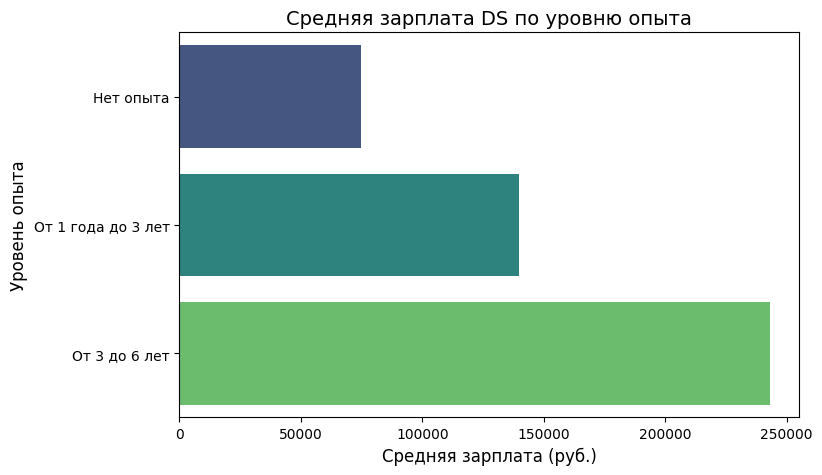

In [52]:
# Выведем столбчатую диаграмму средней зарплаты DS по уровню опыта
salary_clean = result_6_6.dropna()                                          # Задаем размеры фигуры

plt.figure(figsize=(8, 5))                                                  # Задаем размеры фигуры
sns.barplot(
            data=salary_clean,                                              # DataFrame с данными
            y='Опыт',                                                 # Значения по оси X
            x='ЗП',                                                     # Значения по оси Y
            palette='viridis'                                               # Цвет: viridis
            )

plt.title('Средняя зарплата DS по уровню опыта', fontsize=14)               # Заголовок графика
plt.xlabel('Средняя зарплата (руб.)', fontsize=12)                          # Подписи осей
plt.ylabel('Уровень опыта', fontsize=12)                                    # Подписи осей
plt.show()                                                                  # Отображаем график


### Исходя из предметного анализа вакансий можно сделать следующие выводы:

1. 1771 вакансия связана с данными - 3.6% от всех вакансий.  

2. Рынок DS для джуниоров крайне узок - всего 52 вакансии (2.9% от всех DS-вакансий).  

3. По ключевым навыкам:
    * Каждая пятая вакансия требует знание Python (20% вакансий);
    * Каждая восьмая вакансия требует знаний SQL / Postgres (13% вакансий);
    * Остальные 67% вакансий либо не указывают ключевые навыки, либо требуют другие технологии (R, Spark, Tableau и др.).

4. Средний DS должен владеть 6-7 технологиями - работодатели ждут широкого стека.

5. Зарплатный рост в DS очень быстрый:

    * Junior: 75 тыс. рублей;
    * Middle (1-3 года): 140 тыс. рублей (+87%);
    * Senior (3-6 лет): 243 тыс. рублей (+74%).  

6. Вакансии для экспертов (6+ лет) не публикуются открыто - вероятно, закрываются через личные связи.


# Общий вывод по проекту

### <center> 1. Общая структура рынка: гиперконцентрация и скрытые данные.

Факты:  

* Топ-30 регионов дают 78% всех вакансий, при этом Москва и Санкт-Петербург аккумулируют 17% предложений.
* 49% вакансий не содержат информации о зарплате, 35,8% работодателей не указали сферу деятельности.

Тенденция: Рынок труда в РФ остаётся ярко выраженным столичным - работодатели предпочитают публиковать вакансии в крупных городах, где выше концентрация квалифицированных кадров. При этом отсутствие данных о зарплате и отраслевой принадлежности мешает точной оценке реальных предложений.

Прогноз: С развитием удалённой работы доля вакансий в регионах-миллионниках будет расти, но Москва сохранит лидерство за счёт централизованности крупных IT-компаний.

### <center> 2. Работодатели: лидерство IT-гигантов и скрытый средний бизнес.
Факты:
* Яндекс => 1 933 вакансии.
* 8 419 работодателей (36%) не указали отрасль, но среди явно заявленных «Разработка ПО» доминирует (3 553 компании).
* Среднее число вакансий на одного работодателя = 2.1 => большинство компаний ищут 1-2 сотрудников.

Анализ: Огромный разрыв между лидером и остальными объясняется не только масштабом Яндекса, но и стратегией публикации: крупные IT-компании используют open-найм для массового подбора (стажёры, middle, удалёнщики).  

Прогноз: В ближайшие 1-2 года число вакансий от крупных IT-компаний продолжит расти.  

### <center> 3. Форматы занятости: классика рулит, но удалёнка укрепляется:
Факты:
* 72% вакансий => "Полный день + Полная занятость".
* 18% => удалённая работа (почти все - с полной занятостью).
* Стажировки почти всегда очные (92%).
* Проектная работа - менее 1%.

Тенденция: Рост удалённых вакансий в IT и консалтинге - это следствие пандемийного сдвига и глобального тренда на гибридные форматы. При этом производственные, сервисные и государственные организации остаются консервативными.

Прогноз: Через 2-3 года удалёнка может достичь 25-30% от всех вакансий в офисных профессиях, но для начальных позиций (стажировки, джуниоры) компании будут чаще требовать очное присутствие (контроль и социализация).

### <center> 4. Требования к опыту и зарплаты.

Анализ: Рынок остро нуждается в мидл- и сеньор-специалистах (83% вакансий). Джуниоры испытывают высокую конкуренцию (2,9% от DS-вакансий). Резкий рост зарплаты после первого года объясняется дефицитом реального опыта и низким порогом входа (много соискателей с курсов).

Прогноз: Через 1-2 года количество джуниор-вакансий может увеличиться (компании начнут доращивать кадры под свои технологии), но средняя зарплата для начинающих останется низкой (70-80 тыс.) из-за избытка кандидатов.

### <center> 5. Рынок Data Science:

Тенденция: Работодатели ищут "готовых" специалистов с широким стеком. Это отсеивает многих джуниоров. Отсутствие открытых вакансий для экспертов (6+ лет) говорит о том, что компании переманивают таких сотрудников через личные связи или закрытые каналы.

Прогноз: В ближайшие годы будет расти спрос на ML-инженеров (ближе к production) и аналитиков данных (SQL + BI), а классический "DS-универсал" станет реже встречаться.